In [ ]:
# pip install
#    pandas matplotlib numpy
#    nltk seaborn sklearn gensim pyldavis
#    wordcloud textblob spacy textstat

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset separately (This dataset is the one being used inside the model for fine tuning)

In [2]:
df_ai = pd.read_csv("../data/for_eda/generated_1.csv")
df_human = pd.read_csv("../data/for_eda/generated_0.csv")

In [3]:
def truncate_to_300_words(text):
    if isinstance(text, str):
        words = text.split()
        return " ".join(words[:300])
    return text

In [4]:
def text_length(text):
    if isinstance(text, str):
        return len(text.split())
    return 0

In [5]:
# truncate text length to 300 words
df_ai["text"] = df_ai["text"].apply(truncate_to_300_words)
df_human["text"] = df_human["text"].apply(truncate_to_300_words)
# update text_length
df_ai["text_length"] = df_ai["text"].apply(text_length)
df_human["text_length"] = df_human["text"].apply(text_length)

In [11]:
df_human.head()

,text,generated,text_length
0,film years slave proved slavery worldwide issu...,0,300
1,social media examiner ’ video social media ini...,0,212
2,world shattered russia ’ attack ukraine past d...,0,191
3,table contents facts issue holding reasoning r...,0,219
4,charles schwab forprofit corporation whose mai...,0,204


In [12]:
df_ai.head()

,text,generated,text_length
0,th march first infantry regiment set towards t...,1,141
1,important note finding whether break occurs co...,1,130
2,nyāya sūtras significant set philosophical wor...,1,143
3,ancient times priests amun held dominance sout...,1,133
4,young woman whose identity remains unknown sud...,1,128


Analyzing text statistics

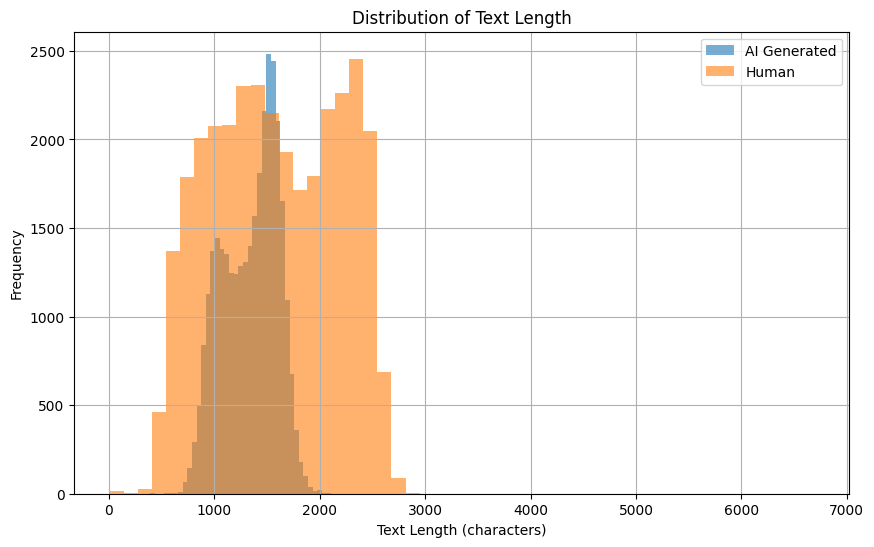

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df_ai["text"].str.len(), bins=50, alpha=0.6, label="AI Generated")
plt.hist(df_human["text"].str.len(), bins=50, alpha=0.6, label="Human")

plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length")
plt.legend()
plt.grid(True)

plt.show()

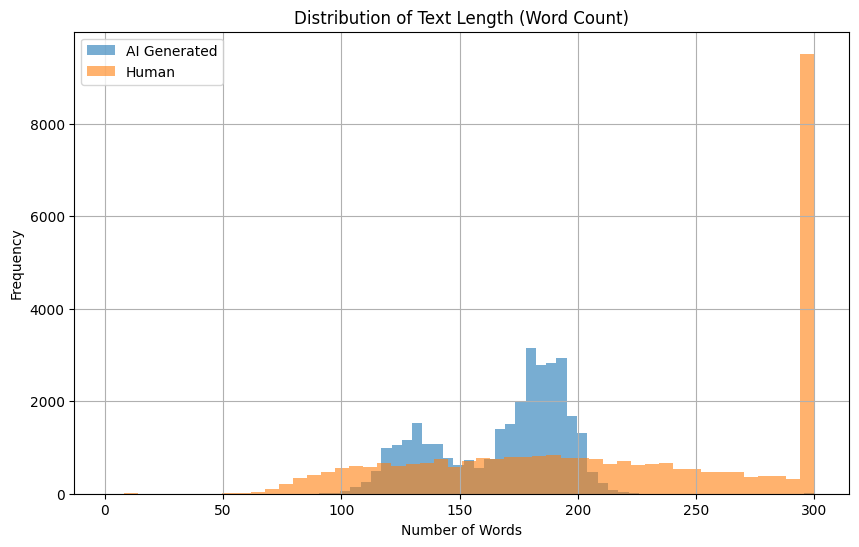

In [ ]:
plt.figure(figsize=(10, 6))

ai_word_counts = df_ai["text"].str.split().map(len)
human_word_counts = df_human["text"].str.split().map(len)

plt.hist(ai_word_counts, bins=50, alpha=0.6, label="AI Generated")
plt.hist(human_word_counts, bins=50, alpha=0.6, label="Human")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length (Word Count)")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Combine both
df = pd.concat([df_ai, df_human], ignore_index=True)

# Map labels for clarity
df["label"] = df["generated"].map({1: "AI", 0: "Human"})

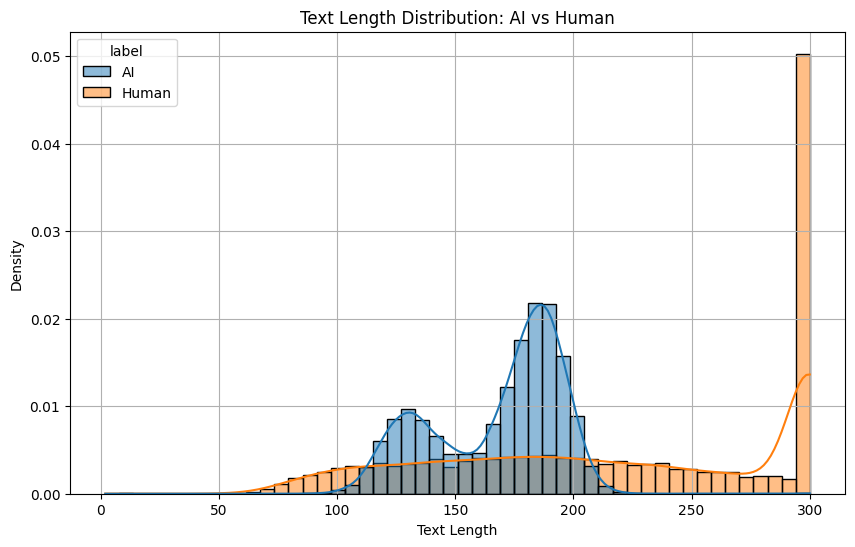

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Text Length Distribution: AI vs Human")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [ ]:
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def get_top_words(text_series, n=20):
    words = []
    
    for text in text_series.astype(str):
        tokens = re.findall(r"\b[a-zA-Z]+\b", text.lower())
        filtered = [w for w in tokens if w not in stop_words]
        words.extend(filtered)
    
    word_counts = Counter(words)
    return pd.DataFrame(word_counts.most_common(n), columns=["word", "count"])

top_ai = get_top_words(df[df["label"] == "AI"]["text"], 20)
top_human = get_top_words(df[df["label"] == "Human"]["text"], 20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kinga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


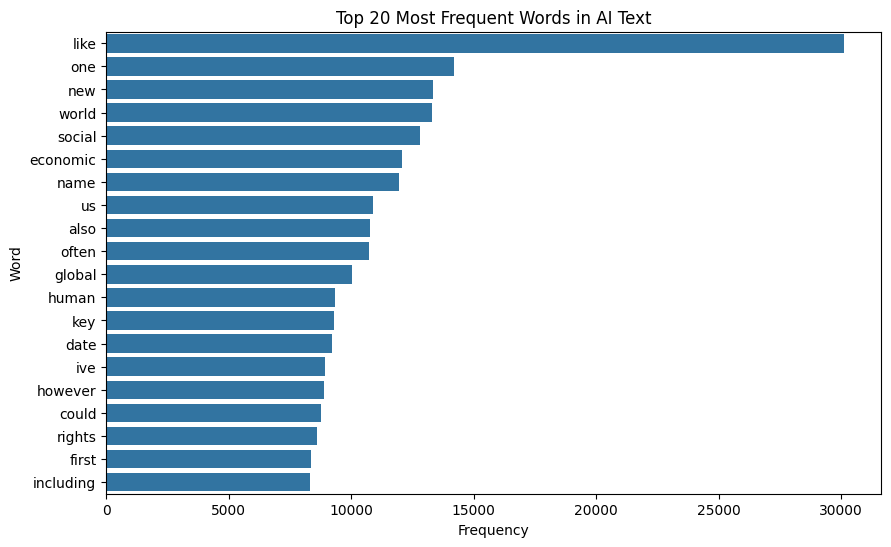

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_ai, x="count", y="word")

plt.title("Top 20 Most Frequent Words in AI Text")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

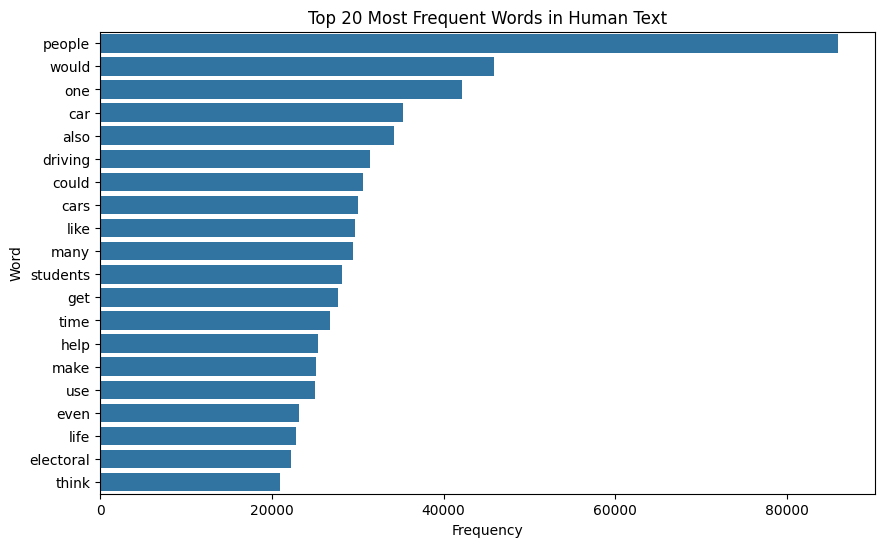

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_human, x="count", y="word")

plt.title("Top 20 Most Frequent Words in Human Text")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [19]:
!pip install wordcloud


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
def clean_text(text_series):
    words = []
    
    for text in text_series.astype(str):
        tokens = re.findall(r"\b[a-zA-Z]+\b", text.lower())
        filtered = [w for w in tokens if w not in stop_words]
        words.extend(filtered)
    
    return " ".join(words)

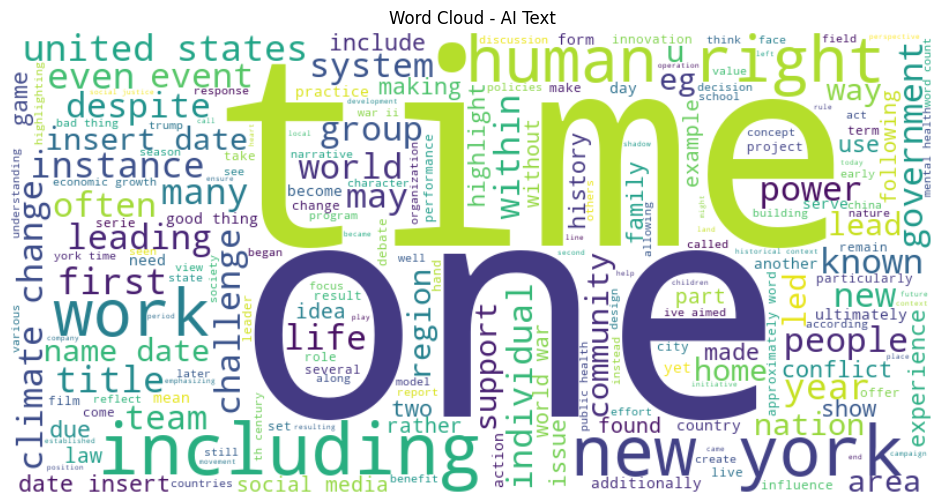

In [22]:
from wordcloud import WordCloud

ai_text = clean_text(df[df["generated"] == 1]["text"])

wordcloud_ai = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(ai_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_ai, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - AI Text")
plt.show()

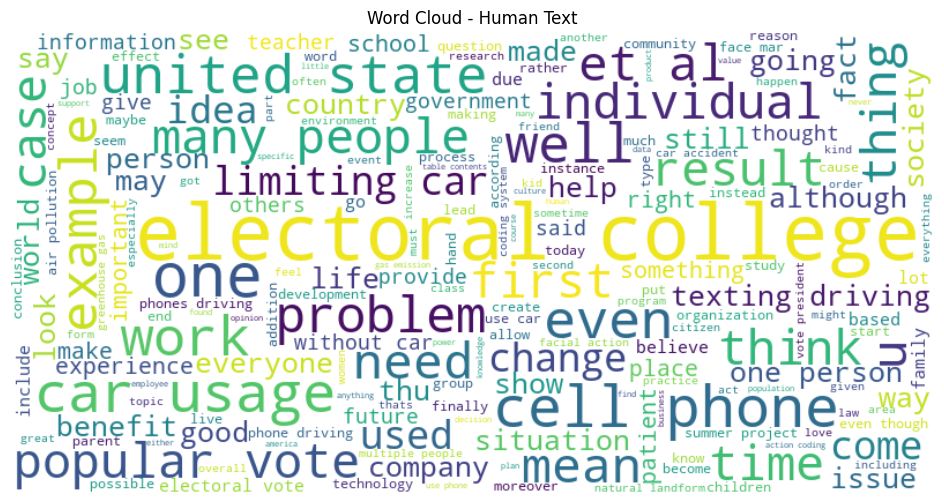

In [23]:
human_text = clean_text(df[df["generated"] == 0]["text"])

wordcloud_human = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(human_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_human, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Human Text")
plt.show()

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         63464 non-null  str  
 1   generated    63464 non-null  int64
 2   text_length  63464 non-null  int64
 3   label        63464 non-null  str  
dtypes: int64(2), str(2)
memory usage: 91.1 MB


In [25]:
df.head()

,text,generated,text_length,label
0,th march first infantry regiment set towards t...,1,141,AI
1,important note finding whether break occurs co...,1,130,AI
2,nyāya sūtras significant set philosophical wor...,1,143,AI
3,ancient times priests amun held dominance sout...,1,133,AI
4,young woman whose identity remains unknown sud...,1,128,AI


In [27]:
import random

def random_truncate(text, min_len=150, max_len=230):
    target = random.randint(min_len, max_len)
    return text[:target]

df['text'] = df['text'].apply(random_truncate)

In [28]:
# update text_length
df["text_length"] = df["text"].apply(text_length)

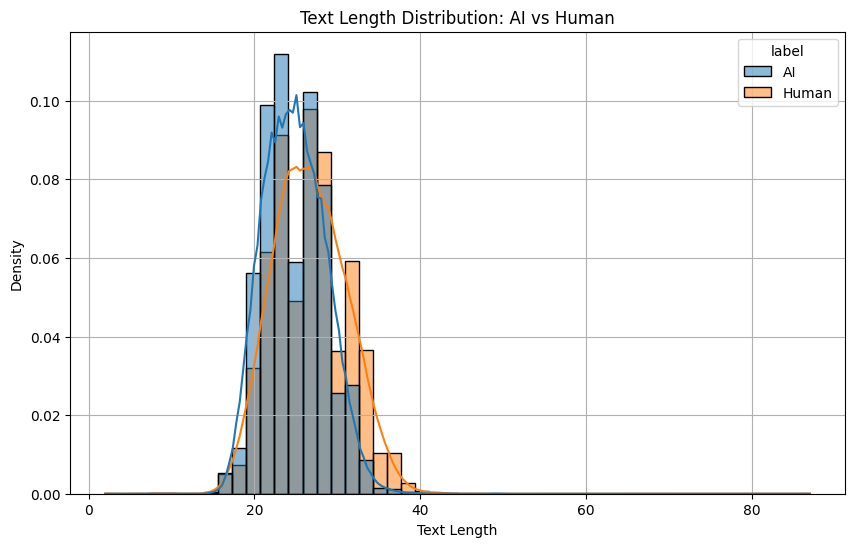

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Text Length Distribution: AI vs Human")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.grid(True)
plt.show()